# Simulation Manuscript Figures

A notebook that takes output from the simulation fitting notebook and makes the figures for the manuscript.

In [1]:
import warnings
import pprint
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
import seaborn as sns
import scipy.stats
import math

Read in data from input files generated from the simulation and fitting models to simulated data.

In [2]:
# Define the location of the data
simdir = ''
# datadir = simdir
datadir = os.path.join('output/', simdir)

# Read in simulated mutational effects and functional scores
simulated_muteffects_df = pd.read_csv(f"{datadir}/simulated_muteffects.csv")
simulated_func_scores_df = pd.read_csv(f"{datadir}/simulated_func_scores.csv")

# Read in inferred mutational effects from each model fit to each simulated dataset
model_df = pd.read_csv(os.path.join(datadir, 'collection_muts.csv'))

# Read in summary stats quantifying correlations between inferred and ground-truth mutational effects
model_vs_truth_beta_shift_df = pd.read_csv(f"{datadir}/model_vs_truth_beta_shift.csv")#.astype({"scale_coeff_lasso_shift": str})
model_vs_truth_beta_shift_df["scale_coeff_lasso_shift"] = [f"{l:.1e}" for l in model_vs_truth_beta_shift_df["scale_coeff_lasso_shift"]]
model_vs_truth_beta_shift_df["r2"] = model_vs_truth_beta_shift_df["corr"]**2

# Read in summary stats quantifying correlations between inferred shifts between replicates
library_replicate_correlation_df = pd.read_csv(f"{datadir}/library_replicate_correlation.csv")#.astype({"scale_coeff_lasso_shift": str})
library_replicate_correlation_df["scale_coeff_lasso_shift"] = [f"{l:.1e}" for l in library_replicate_correlation_df["scale_coeff_lasso_shift"]]
library_replicate_correlation_df["r2"] = library_replicate_correlation_df["correlation"]**2

# Read in summary stats quantifying sparsity
fit_sparsity_df = pd.read_csv(f"{datadir}/fit_sparsity.csv")#.astype({"scale_coeff_lasso_shift": str})
fit_sparsity_df["scale_coeff_lasso_shift"] = [f"{l:.1e}" for l in fit_sparsity_df["scale_coeff_lasso_shift"]]
fit_sparsity_df["sparsity"] = fit_sparsity_df["sparsity"] * 100

# Read in summary stats quantifying cross-validation loss
cross_validation_loss_df = pd.read_csv(f"{datadir}/cross_validation_loss.csv")#.astype({"scale_coeff_lasso_shift": str})
cross_validation_loss_df["scale_coeff_lasso_shift"] = [f"{l:.1e}" for l in cross_validation_loss_df.scale_coeff_lasso_shift.values]

In [3]:
cross_validation_loss_df

,scale_coeff_lasso_shift,library,measurement_type,dataset,loss,lib_dataset
0,0.0e+00,lib_1,observed_phenotype,total_training,0.000231,lib_1 total_training
1,5.0e-06,lib_1,observed_phenotype,total_training,0.000273,lib_1 total_training
2,1.0e-05,lib_1,observed_phenotype,total_training,0.000344,lib_1 total_training
3,2.0e-05,lib_1,observed_phenotype,total_training,0.000545,lib_1 total_training
4,4.0e-05,lib_1,observed_phenotype,total_training,0.001181,lib_1 total_training
...,...,...,...,...,...,...
103,4.0e-05,lib_2,tight_bottle,total_validation,0.439831,lib_2 total_validation
104,8.0e-05,lib_2,tight_bottle,total_validation,0.439058,lib_2 total_validation
105,1.6e-04,lib_2,tight_bottle,total_validation,0.442694,lib_2 total_validation
106,3.2e-04,lib_2,tight_bottle,total_validation,0.449177,lib_2 total_validation


Make a heatmap of simulated shifts.

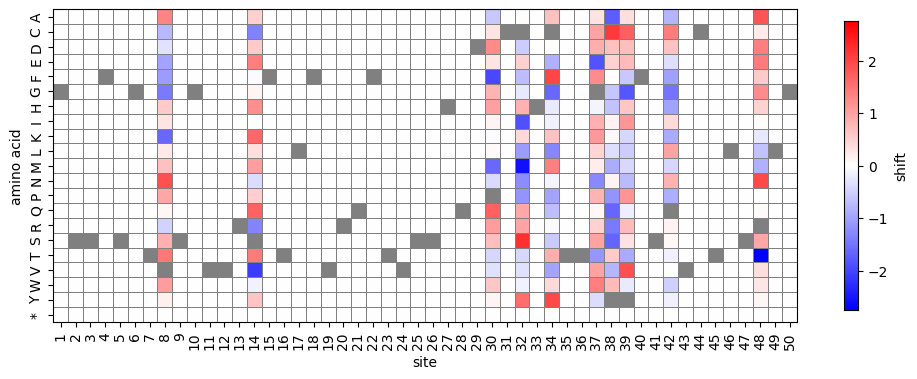

In [5]:
# saveas=''

# Get data in matrix matching heatmap
aas = [
    'A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N',
    'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y', '*'
]
metrics = ['shift']# , 'beta_h1']
for metric in metrics:
    
    # Get data and clip values at -10, so that lower betas don't wash out signal
    data = simulated_muteffects_df.pivot_table(index='mut_aa', columns='site', values=metric)
    data = data.clip(lower=-10)

    # Plot heatmap
    plt.figure(figsize=[12,5])
    g = sns.heatmap(
        data.loc[aas], cmap='bwr', square=True, center=0, vmin=-2.75, vmax=2.75,
        linewidths=0.4, linecolor='0.5', cbar_kws={"shrink":0.75, 'label':metric}
    )
    g.set_facecolor('0.5')
    plt.ylabel('amino acid')
    sns.despine(right=False, top=False)
    plt.show()

Plot the correlation between inferred vs. ground-truth beta parameters for a given replicate model, lasso weight, and level of simulated noise.

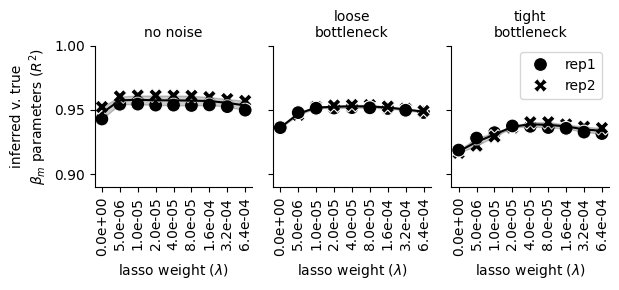

In [6]:
# Get data and rename labels
data = model_vs_truth_beta_shift_df[
    model_vs_truth_beta_shift_df['parameter'] == 'beta'
].copy()
data['measurement_type'] = data['measurement_type'].replace({
    'observed_phenotype':'no noise',
    'loose_bottle':'loose\nbottleneck',
    'tight_bottle':'tight\nbottleneck',
})
data['library'] = data['library'].replace({
    'lib_1':'rep1',
    'lib_2':'rep2'
})

# Plot data
data['lambda'] = data['scale_coeff_lasso_shift'].astype('float')
data.sort_values('lambda', ascending=True, inplace=True)
g = sns.FacetGrid(
    data, col="measurement_type",
    height=3, aspect=0.7, margin_titles=True,
    col_order = ['no noise', 'loose\nbottleneck', 'tight\nbottleneck']
)
g.map_dataframe(
    sns.scatterplot, x='scale_coeff_lasso_shift', y='r2',
    style='library', markers=['o','X'], s=100, color='k',
    style_order=['rep1', 'rep2']
)
g.map_dataframe(
    sns.lineplot, x='scale_coeff_lasso_shift', y='r2',
    legend=False, color='k'
)
g.set_titles(col_template="{col_name}")
g.set(ylim=[round(data['r2'].min(), 1)-0.01, 1.0], yticks=[0.9, 0.95, 1.0])
g.set_axis_labels(r"lasso weight ($\lambda$)", "inferred v. true\n"+ r"$\beta_m$ parameters ($R^2$)")
g.set_xticklabels(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

For a given model fit, plot the correlation between inferred and ground-truth betas.

In [8]:
model_df

,mutation,library,measurement_type,scale_coeff_lasso_shift,predicted_shift_h2,true_shift
0,C31*,lib_1,observed_phenotype,0.00000,-0.599327,0.000000
1,C31A,lib_1,observed_phenotype,0.00000,0.001171,0.000000
2,C31D,lib_1,observed_phenotype,0.00000,0.008174,0.000000
3,C31E,lib_1,observed_phenotype,0.00000,0.016727,0.000000
4,C31F,lib_1,observed_phenotype,0.00000,0.000772,0.000000
...,...,...,...,...,...,...
53995,Y39R,lib_2,tight_bottle,0.00064,0.000000,0.734268
53996,Y39S,lib_2,tight_bottle,0.00064,0.000000,0.309565
53997,Y39T,lib_2,tight_bottle,0.00064,0.000000,-0.905451
53998,Y39V,lib_2,tight_bottle,0.00064,0.000000,1.881393


In [7]:
# Get data
measurement_type = 'observed_phenotype' # 'loose_bottle' # 'tight_bottle' # 
scale_coeff_lasso_shift = 0 # 5.0e-06 # 
data = model_df[
    (model_df['library'] == 'lib_1') &
    (model_df['measurement_type'] == measurement_type) &
    (model_df['scale_coeff_lasso_shift'] == scale_coeff_lasso_shift)
].copy()

# Report R^2
(r, p) = scipy.stats.pearsonr(data['predicted_beta_h1'], data['true_beta'])
print('R^2', round(r**2, 2))

# Plot correlation between inferred and ground-truth betas
measurement_type_title_dict = {
    'observed_phenotype' : 'no noise',
    'loose_bottle' : 'loose bottleneck',
    'tight_bottle' : 'tight bottleneck'
}
plt.figure(figsize=[2.5,2.5])
sns.scatterplot(x='predicted_beta', y='true_beta', data=data, alpha=0.5, s=50)
plt.xlabel(r'inferred $\beta_m$')
plt.ylabel(r'ground-truth $\beta_m$')
plt.title(f'{measurement_type_title_dict[measurement_type]}, $\lambda={scale_coeff_lasso_shift}$')
sns.despine()
plt.show()

KeyError: 'predicted_beta'

Make scatter plots showing the correlation between predicted and ground-truth shifts for a model at a given lasso weight (rows) and level of simulated noise (columns).

/home/hhaddox/miniconda3/envs/multidms4/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/hhaddox/miniconda3/envs/multidms4/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/hhaddox/miniconda3/envs/multidms4/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/hhaddox/miniconda3/envs/multidms4/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axe

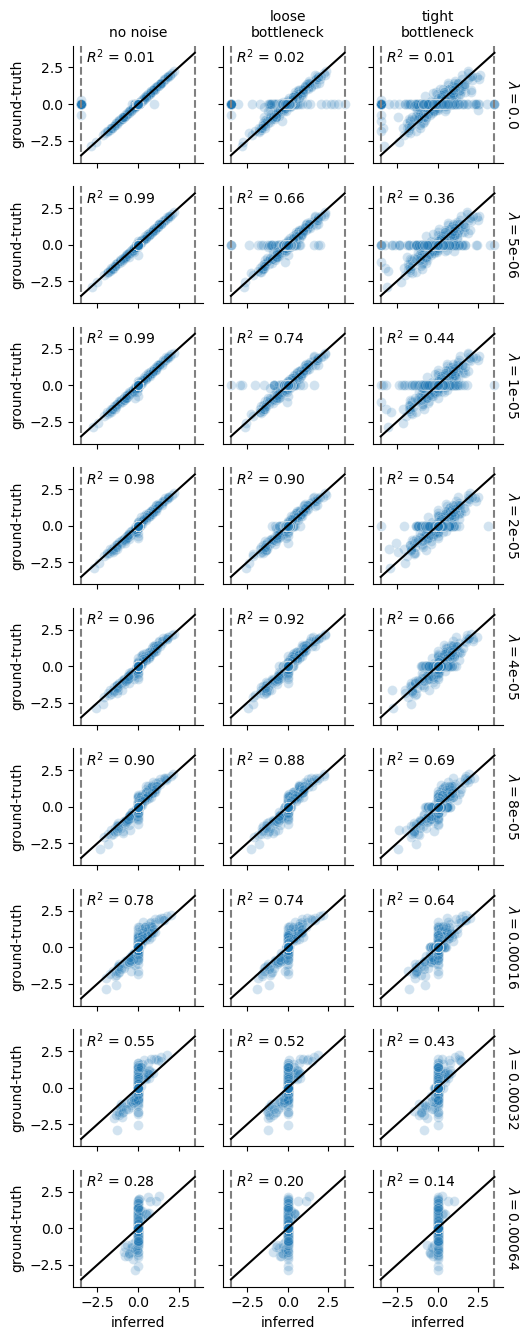

In [6]:
# Get data and update column values
data = model_df[model_df['library'] == 'lib_1'].copy()
data['clipped_predicted_shift_h2'] = data['predicted_shift_h2'].clip(lower=-3.5, upper=3.5)
data['predicted_beta'] = data['predicted_beta'].clip(lower=-15)
data['measurement_type'] = data['measurement_type'].replace({
    'observed_phenotype':'no noise',
    'loose_bottle':'loose\nbottleneck',
    'tight_bottle':'tight\nbottleneck',
})

# Plot data
data = data.sort_values(by=['site', 'wt_aa', 'mut_aa'])
g = sns.FacetGrid(
    data, col="measurement_type", row="scale_coeff_lasso_shift",
    height=1.5, aspect=1.2, margin_titles=True
)
g.map_dataframe(
    sns.scatterplot, x='clipped_predicted_shift_h2', y='true_shift',
    s=50, alpha=0.2,
)
g.refline(x=-3.5)
g.refline(x=3.5)
def const_line(*args, **kwargs):
    plt.plot([-3.5, 3.5], [-3.5, 3.5], c='k')
g.map(const_line)

def corrfunc(data, ax=None, **kws):
    """Plot the correlation coefficient in the top left hand corner of a plot."""
    r, _ = scipy.stats.pearsonr(data['predicted_shift_h2'], data['true_shift'])
    r = math.pow(r, 2)
    ax = ax or plt.gca()
    ax.annotate(f'$R^2$ = {r:.2f}', xy=(.1, .85), xycoords=ax.transAxes)
g.map_dataframe(corrfunc)

g.set_axis_labels("inferred", "ground-truth")
g.set_titles(col_template="{col_name}", row_template=r"$\lambda = ${row_name}")
g.set(xlim=[-4,4], ylim=[-4,4], xticks=[-2.5, 0, 2.5], yticks=[-2.5, 0, 2.5])
plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.show()

For a given model fit, plot the distribution of beta and shift parameters for mutations with ground-truth shifts of zero.

<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_11193/1907359123.py:23: SyntaxWarning: invalid escape sequence '\l'
  title=f'$\lambda$={lasso_weight}' # measurement_type_title_dict[measurement_type]+f', $\lambda$={lasso_weight}'


lasso_weight, sparsity
0 , 0.0
5e-06 , 0.83


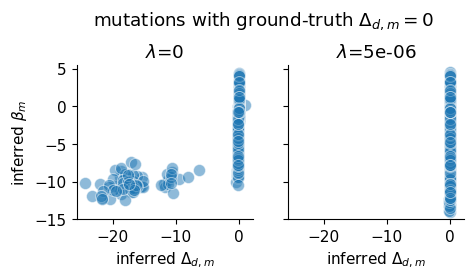

In [19]:
# Get data
measurement_type = 'observed_phenotype' # 'loose_bottle' # 'tight_bottle' # 
lasso_weights = [0, 5.0e-06] # 
(fig, axs) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=[5,2])
print('lasso_weight, sparsity')
for (i, lasso_weight) in enumerate(lasso_weights):

    data = model_df[
        (model_df['library'] == 'lib_1') &
        (model_df['true_shift'] == 0) &
        (model_df['measurement_type'] == measurement_type) &
        (model_df['scale_coeff_lasso_shift'] == lasso_weight)
    ].copy()

    print(lasso_weight, ',', round(sum(data['predicted_shift_h2'] == 0)/len(data), 2))

    sns.scatterplot(
        x='predicted_shift_h2', y='predicted_beta', data=data, alpha=0.5, s=75,
        ax=axs[i]
    )
    axs[i].set(
        xlabel=r'inferred $\Delta_{d,m}$',
        title=f'$\lambda$={lasso_weight}' # measurement_type_title_dict[measurement_type]+f', $\lambda$={lasso_weight}'
    )

axs[0].set(ylabel=r'inferred $\beta_m$')
plt.suptitle(r'mutations with ground-truth $\Delta_{d,m}=0$', y=1.16)
sns.despine()
plt.show()

Make the main figure from the manuscript (Figure 2).

In [22]:
# Helper function used for visualization in the following examples
def identify_axes(ax_dict, fontsize=8):
    """
    Helper to identify the Axes in the examples below.

    Draws the label in a large font in the center of the Axes.

    Parameters
    ----------
    ax_dict : dict[str, Axes]
        Mapping between the title / label and the Axes.
    fontsize : int, optional
        How big the label should be.
    """
    kw = dict(ha="center", va="center", fontsize=fontsize, color="darkgrey")
    for k, ax in ax_dict.items():
        ax.text(0.5, 0.5, k, transform=ax.transAxes, **kw)


In [23]:
rc_kwargs = {
    'legend.frameon': False,
    "font.size" : 11,
    "font.weight" : "normal"
}

plt.rcParams.update(**rc_kwargs)
%matplotlib inline

/home/jgallowa/mambaforge/envs/multidms-dev/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/jgallowa/mambaforge/envs/multidms-dev/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/jgallowa/mambaforge/envs/multidms-dev/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

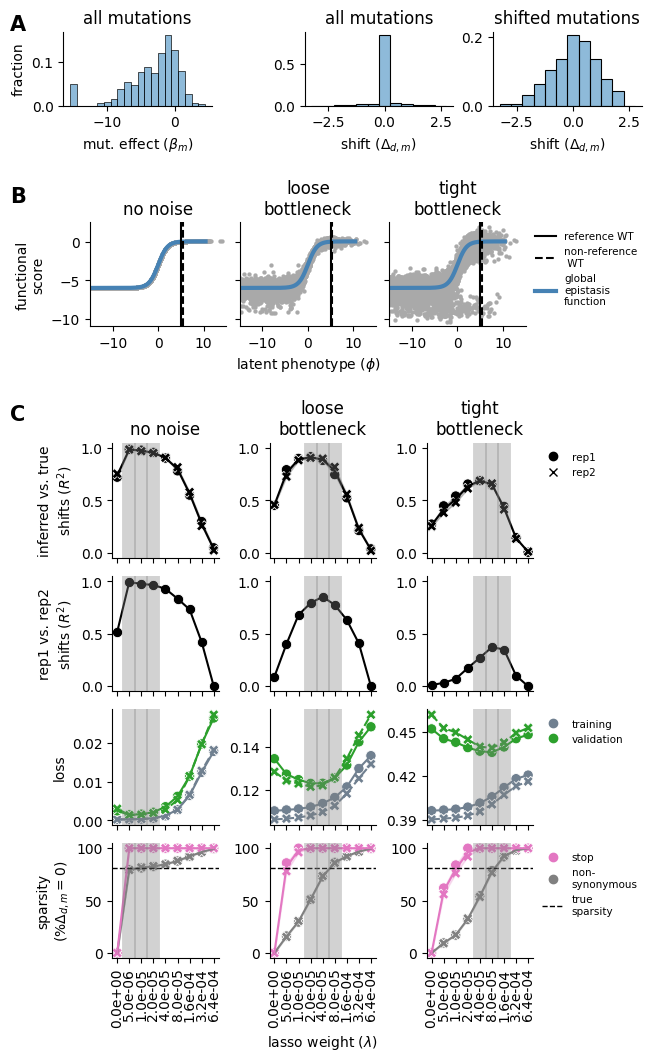

In [8]:
# Knobs 
setup = True
if setup:
    bottlenecks = {
        "observed_phenotype": "no noise", # title
        "loose_bottle": "loose\nbottleneck",
        "tight_bottle": "tight\nbottleneck"
    }

    observed_phenotype_ylabel = "functional\nscore"
    model_truth_corr_ylabel = "inferred vs. true\nshifts $(R^2)$"
    lib_corr_ylabel = "rep1 vs. rep2\nshifts $(R^2)$"
    loss_ylabel = "loss"
    sparsity_ylabel = "sparsity\n$(\%\Delta_{d,m}=0)$"

    # xlabels
    beta_dist = r"mut. effect $(\beta_{m})$"
    shift_dist = r"shift ($\Delta_{d,m}$)"
    latent_phenotype = "latent phenotype ($\phi$)"
    lasso_strength = f"lasso weight ($\lambda$)"

    mut_type_palette={"nonsynonymous":"grey", "stop":"#E377C2"}
    dataset_palette={"total_training":"slategrey", "total_validation":"#2CA02C"}

    ref_wildtype_color = "black"
    nonref_wildtype_color = "black"    
    groundtruth_color = "steelblue"

    # x scale for latent phenotype plots
    x_scale = (-15, 15)
    point_size = 55

    # create main figure
    fig = plt.figure(layout="constrained", figsize=(6.4, 10.5))

    # create subfigures
    A, B, C = fig.subfigures(nrows=3, ncols=1, height_ratios=[0.15, 0.2, 0.65], hspace=0.05)

    # create axes
    axd_a = A.subplot_mosaic(
        [["beta_dist", "empty", "shift_dist", "shift_dist_nonzero"]],
        gridspec_kw={"width_ratios": [1, 0.3, 1, 1], "wspace": 0.05, "hspace": 0.05}
    )
    axd_b = B.subplot_mosaic(
        [["observed_phenotype_latent_measured", "loose_bottle_latent_measured", "tight_bottle_latent_measured"]],
        sharey=True 
    )
    axd_c = C.subplot_mosaic(
        [
            [f"{bottle}_shift_acc" for bottle in bottlenecks.keys()],
            [f"{bottle}_shift_rep" for bottle in bottlenecks.keys()],
            [f"{bottle}_shift_cv" for bottle in bottlenecks.keys()],
            [f"{bottle}_shift_sparse" for bottle in bottlenecks.keys()]
        ],
        sharex=True,
        gridspec_kw={"hspace": 0.05}
    )
# Add subpanel labels
axd_a["empty"].set_visible(False)

identify_ax = False
if identify_ax:
    identify_axes(axd_a)
    identify_axes(axd_b)
    identify_axes(axd_c)

# MUTATION EFFECTS
iter_ax = axd_a['beta_dist']
if True:
    sns.histplot(
        simulated_muteffects_df, 
        x="beta_h1", 
        ax=iter_ax,
        stat='probability',
        alpha=0.5,
        bins = np.arange(-15.5, 5.5, 1.0)
    )
    iter_ax.set_xlabel(r"mut. effect $(\beta_m)$")
    iter_ax.set_ylabel("fraction")
    iter_ax.set_title("all mutations")

# SHIFT EFFECTS
iter_ax = axd_a['shift_dist_nonzero']
if True:
    sns.histplot(
        simulated_muteffects_df.query("shifted_site and ~mutation.str.contains('\*')"), 
        x="shift", 
        ax=iter_ax,
        stat='probability',
        alpha=0.5,
        bins=np.arange(-3.25, 3.25, 0.5)
    )
    # remove y label
    iter_ax.set_ylabel(None)
    iter_ax.set_xlabel('shift ($\Delta_{d,m}$)')
    iter_ax.set_title("shifted mutations")

# SHIFT EFFECTS
iter_ax = axd_a['shift_dist']
if True:
    sns.histplot(
        simulated_muteffects_df, 
        x="shift", 
        ax=iter_ax,
        stat='probability',
        alpha=0.5,
        bins=np.arange(-3.25, 3.25, 0.5)
    )
    # remove y label
    iter_ax.set_ylabel(None)
    iter_ax.set_xlabel('shift ($\Delta_{d,m}$)')
    iter_ax.set_title("all mutations")

# ground truth line points
gt_points = (
    simulated_func_scores_df
    .query(f"func_score_type == 'observed_phenotype' and latent_phenotype > @x_scale[0] and latent_phenotype < @x_scale[1]")
    .sample(1500)
    [["latent_phenotype", "func_score"]]
    .rename(columns={"latent_phenotype": "x", "func_score": "y"})
    .sort_values("x")
)

# get the wildtyle latent phenotype
reference_wildtype_latent_phenotype = (
    simulated_func_scores_df
    .query("variant_class == 'wildtype' and homolog == 'h1'")
    .latent_phenotype
    .values[0]
)

non_reference_wildtype_latent_phenotype = (
    simulated_func_scores_df
    .query("variant_class == 'wildtype' and homolog == 'h2'")
    .latent_phenotype
    .values[0]
)

true_sparsity = (
    (len(simulated_muteffects_df.query("shift == 0")) / len(simulated_muteffects_df)) * 100
)

chosen_lassos = {
    ("default", "observed_phenotype"): ["5.0e-06", "1.0e-05", "2.0e-05"],
    ("default", "loose_bottle"): ["2.0e-05", "4.0e-05", "8.0e-05"],
    ("default", "tight_bottle"): ["4.0e-05", "8.0e-05", "1.6e-04"],

    ("beta_ridge_1e-7", "observed_phenotype"): ["5.0e-06", "1.0e-05", "2.0e-05"],
    ("beta_ridge_1e-7", "loose_bottle"): ["2.0e-05", "4.0e-05", "8.0e-05"],
    ("beta_ridge_1e-7", "tight_bottle"): ["4.0e-05", "8.0e-05", "1.6e-04"],

    ("n_shifted_identical_sites_1-n_shifted_non_identical_sites_1-scale_coeff_ridge_beta_1e-07", "observed_phenotype"): ["5.0e-06", "1.0e-05", "2.0e-05"],
    ("n_shifted_identical_sites_1-n_shifted_non_identical_sites_1-scale_coeff_ridge_beta_1e-07", "loose_bottle"): ["4.0e-05", "8.0e-05", "1.6e-04"],
    ("n_shifted_identical_sites_1-n_shifted_non_identical_sites_1-scale_coeff_ridge_beta_1e-07", "tight_bottle"): ["8.0e-05", "1.6e-04", "3.2e-04"],

    ("shift_gauss_variance_0.2-scale_coeff_ridge_beta_1e-07", "observed_phenotype"): ["5.0e-06", "1.0e-05", "2.0e-05"],
    ("shift_gauss_variance_0.2-scale_coeff_ridge_beta_1e-07", "loose_bottle"): ["2.0e-05", "4.0e-05", "8.0e-05"],
    ("shift_gauss_variance_0.2-scale_coeff_ridge_beta_1e-07", "tight_bottle"): ["4.0e-05", "8.0e-05", "1.6e-04"],
}


# make all subplots in c
for bottleneck, name in bottlenecks.items():

    # LATENT PHENOTYPE VS FUNCTIONAL SCORE
    iter_ax = axd_b[f"{bottleneck}_latent_measured"]
    if True:
        # Plot the functional scores as a function of the latent phenotype
        sns.scatterplot(
            simulated_func_scores_df.query(f"library == 'lib_1' and func_score_type == @bottleneck").sample(8000), 
            x="latent_phenotype",
            y="func_score",
            ax=iter_ax,
            s=8,
            c="darkgrey",
            edgecolor="darkgrey"
        )

        sns.lineplot(
            data=gt_points,
            x="x",
            y="y",
            ax=iter_ax,
            color=groundtruth_color,
            linestyle="-",
            linewidth=3
        )

        # add wildtype vertical lines
        iter_ax.axvline(
            reference_wildtype_latent_phenotype,
            color=ref_wildtype_color,
        )
        iter_ax.axvline(
            non_reference_wildtype_latent_phenotype,
            color=nonref_wildtype_color,
            linestyle="--"
        )

        iter_ax.set_title(name)
        iter_ax.set_xlim(x_scale)
        if bottleneck == "observed_phenotype":
            iter_ax.set_ylabel(observed_phenotype_ylabel)

        if bottleneck == "loose_bottle":
            iter_ax.set_xlabel(latent_phenotype)
        else:
            iter_ax.set_xlabel(None)

    # SHIFT RECOVERY
    iter_ax = axd_c[f"{bottleneck}_shift_acc"]
    if True:
        # plot the shift model vs truth
        sns.scatterplot(
            (
                model_vs_truth_beta_shift_df
                .query(
                    f"measurement_type == @bottleneck and parameter == 'shift'"
                )
            ),
            x="scale_coeff_lasso_shift",
            y="r2",
            ax=iter_ax,
            style="library",
            legend=False,
            s=point_size,
            c="black"
        )

        sns.lineplot(
            (
                model_vs_truth_beta_shift_df
                .query(
                    f"measurement_type == @bottleneck and parameter == 'shift'"
                )
            ),
            x="scale_coeff_lasso_shift",
            y="r2",
            ax=iter_ax,
            legend=False,
            c="black"
        )
        iter_ax.set_title(name)
        iter_ax.set_ylim(-0.05, 1.05)
        if bottleneck == "observed_phenotype":
            iter_ax.set_ylabel(model_truth_corr_ylabel)
        else:
            iter_ax.set_ylabel(None)

    # REPLICATE SHIFT CORRELATION
    iter_ax = axd_c[f"{bottleneck}_shift_rep"]
    if True:
        sns.scatterplot(
            library_replicate_correlation_df.query(
                f"measurement_type == @bottleneck and mut_param == 'shift'"
            ),
            x="scale_coeff_lasso_shift",
            y="r2",
            ax=iter_ax,
            c = "black",
            legend=False,
            s=point_size
        )

        sns.lineplot(
            library_replicate_correlation_df.query(
                f"measurement_type == @bottleneck and mut_param == 'shift'"
            ),
            x="scale_coeff_lasso_shift",
            y="r2",
            ax=iter_ax,
            c = "black",
            legend=False 
        )
        iter_ax.set_ylim(-0.05, 1.05)
        if bottleneck == "observed_phenotype":
            iter_ax.set_ylabel(lib_corr_ylabel)
        else:
            iter_ax.set_ylabel(None)

    # SPARSENESS
    iter_ax = axd_c[f"{bottleneck}_shift_sparse"]
    if True:
        # plot the sparseness of the shift model
        sns.scatterplot(
            fit_sparsity_df.query(
                f"measurement_type == @bottleneck and mut_param == 'shift_h2'"
            ),
            x="scale_coeff_lasso_shift",
            y="sparsity",
            ax=iter_ax,
            style="library",
            legend=False,
            s=point_size,
            hue="mut_type",
            palette=mut_type_palette
        )

        sns.lineplot(
            fit_sparsity_df.query(
                f"measurement_type == @bottleneck and mut_param == 'shift_h2'"
            ),
            x="scale_coeff_lasso_shift",
            y="sparsity",
            ax=iter_ax,
            legend=False,
            hue="mut_type",
            palette=mut_type_palette
        )
        iter_ax.set_ylim(-5, 105)
        if bottleneck == "observed_phenotype":
            iter_ax.set_ylabel(sparsity_ylabel)
        else:
            iter_ax.set_ylabel(None)
        # rotate the x axis labels
        iter_ax.set_xticks(
            iter_ax.get_xticks(), 
            iter_ax.get_xticklabels(), 
            rotation=90, 
            fontsize=10
        )

        # add true sparsity line
        iter_ax.axhline(
            true_sparsity,
            color=groundtruth_color,
            linestyle="--",
            linewidth=1,
            c='k'
        )
        if bottleneck == "loose_bottle":
            iter_ax.set_xlabel(lasso_strength)
        else:
            iter_ax.set_xlabel(None)

    # CROSS VALIDATION
    iter_ax = axd_c[f"{bottleneck}_shift_cv"]
    if True:
        # plot the cross validation loss
        sns.scatterplot(
            cross_validation_loss_df.query(
                f"measurement_type == @bottleneck"
            ),
            x="scale_coeff_lasso_shift",
            y="loss",
            ax=iter_ax,
            style="library",
            legend=False,
            s=point_size,
            hue="dataset",
            palette=dataset_palette
        )

        sns.lineplot(
            cross_validation_loss_df.query(
                f"measurement_type == @bottleneck"
            ),
            x="scale_coeff_lasso_shift",
            y="loss",
            ax=iter_ax,
            style="library",
            legend=False,
            hue="dataset",
            palette=dataset_palette
        )

        if bottleneck == "observed_phenotype":
            iter_ax.set_ylabel(loss_ylabel)
        else:
            iter_ax.set_ylabel(None)

touchup = True
if touchup:

    # add panel labels
    axd_a["beta_dist"].text(
        -0.25, 1.10, 
        f"A", 
        ha="right", va="center", 
        size=15,
        weight="bold",
        transform=axd_a["beta_dist"].transAxes
    )

    axd_b["observed_phenotype_latent_measured"].text(
        -0.47, 1.25, 
        f"B", 
        ha="right", va="center", 
        size=15,
        weight="bold",
        transform=axd_b["observed_phenotype_latent_measured"].transAxes
    )

    axd_c["observed_phenotype_shift_acc"].text(
        -0.82, 1.25, 
        f"C", 
        ha="right", va="center", 
        size=15,
        weight="bold",
        transform=axd_c["observed_phenotype_shift_acc"].transAxes
    )

    # despine all axes
    sns.despine(fig)

    # fix up y labels and ticks
    for name, ax  in axd_c.items():

        if name.endswith("shift_acc") or name.endswith("shift_rep"):
            ax.set_yticks([0.0, 0.5, 1.0])
            ax.set_yticklabels(['0.0', '0.5', '1.0'])

        elif name.endswith("shift_sparse"):
            ax.set_yticks([0, 50, 100])
            ax.set_yticklabels(['0', '50', '100'])

        else:
            # manually set ticks and labels  at 0.0, 0.5, 1.0
            # fixing xticks with FixedLocator but also using MaxNLocator to avoid cramped x-labels
            ax.yaxis.set_major_locator(mticker.MaxNLocator(3))
            ticks_loc = ax.get_yticks().tolist()
            ax.yaxis.set_major_locator(mticker.FixedLocator(ticks_loc))
            ax.set_yticklabels(['{:2.2f}'.format(x) for x in ticks_loc])

        # add a thick, and alpha=0.5 vertical line at the chossen lassos
        measurement_type = "_".join(name.split("_")[:2])
        # for lasso in chosen_lassos[(simdir, measurement_type)]:
        for lasso in chosen_lassos[("default", measurement_type)]:
            ax.axvline(
                lasso,
                color="grey",
                linewidth=10,
                alpha=0.35
            )

    # add legends
    iter_ax = axd_b["tight_bottle_latent_measured"]
    black_line = mlines.Line2D(
        [], [], color=ref_wildtype_color, linestyle='-',
        markersize=5, label='reference WT'
    )

    black_dashed = mlines.Line2D(
        [], [], color=nonref_wildtype_color, linestyle='--',
        markersize=5, label='non-reference\n WT'
    )

    # blue dashed line for ground truth
    blue_dashed = mlines.Line2D(
        [], [], color=groundtruth_color, linestyle='-', linewidth=3,
        markersize=5, label='global\nepistasis\nfunction'
    )

    elements = [black_line, black_dashed, blue_dashed]
    
    iter_ax.legend(
        handles=elements, 
        bbox_to_anchor = (1.0, 1.0), 
        loc='upper left', 
        # loc='best', 
        frameon=False, 
        fontsize=7.5, 
    )

    iter_ax = axd_c["tight_bottle_shift_acc"]
    rep_1_circle = mlines.Line2D([], [], color="black", marker='o', linestyle='None',
                          markersize=6, label='rep1')
    rep_2_x = mlines.Line2D([], [], color="black", marker='x', linestyle='None',
                          markersize=6, label='rep2')
    elements = [rep_1_circle, rep_2_x]
    iter_ax.legend(
        handles=elements, 
        bbox_to_anchor = (1.0, 1.0), 
        loc='upper left', 
        frameon=False, 
        fontsize=7.5, 
    )


    iter_ax = axd_c["tight_bottle_shift_sparse"]
    stop_circle = mlines.Line2D([], [], color=mut_type_palette["stop"], marker='o', linestyle='None',
                          markersize=6, label='stop')

    nonsynon_circle = mlines.Line2D([], [], color=mut_type_palette["nonsynonymous"], marker='o', linestyle='None',
                          markersize=6, label='non-\nsynonymous')

    truth_dashed = mlines.Line2D(
        [], [], color='k', linestyle='--', linewidth=1,
        markersize=5, label='true\nsparsity'
    )

    elements = [stop_circle, nonsynon_circle, truth_dashed]
    iter_ax.legend(
        handles=elements, 
        bbox_to_anchor = (1.0, 1.0), 
        loc='upper left', 
        frameon=False, 
        fontsize=7.5, 
    )

    iter_ax = axd_c["tight_bottle_shift_cv"]
    training_circle = mlines.Line2D([], [], color=dataset_palette["total_training"], marker='o', linestyle='None',
                          markersize=6, label='training')
    validation_circle = mlines.Line2D([], [], color=dataset_palette["total_validation"], marker='o', linestyle='None',
                          markersize=6, label='validation')

    elements = [training_circle, validation_circle]
    iter_ax.legend(
        handles=elements, 
        bbox_to_anchor = (1.0, 1.0), 
        loc='upper left', 
        frameon=False, 
        fontsize=7.5, 
    )



save = True
if save:
    fig.savefig(f"{datadir}/main_figure.pdf", bbox_inches="tight")
    fig.savefig(f"{datadir}/main_figure.png", bbox_inches="tight")

$\lambda L_1 = 1e-7$


$\lambda L_1 = 8e-8$



$\lambda L_1 = 1e-8$

Extra plots not in MS

Plot the distributions of simulated betas and shifts

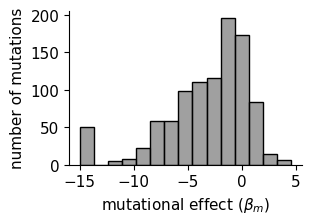

In [12]:
plt.figure(figsize=[3,2])
sns.histplot(x='beta_h1', data=simulated_muteffects_df, bins=15, color='0.5')
plt.xlabel(r'mutational effect ($\beta_m$)')
plt.ylabel('number of mutations')
sns.despine()
plt.show()

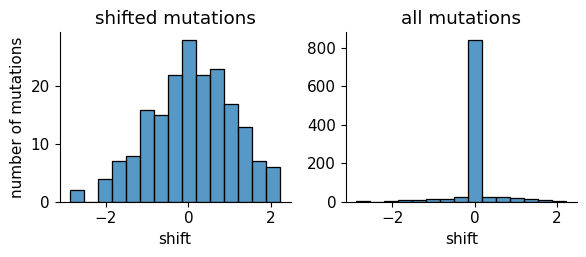

In [13]:
(fig, axs) = plt.subplots(ncols=2, sharex=True, sharey=False, figsize=[6, 2.7])

data = simulated_muteffects_df[simulated_muteffects_df['shift'] != 0]
sns.histplot(x='shift', data=data, bins=15, ax=axs[0])
axs[0].set(xlabel='shift', ylabel='number of mutations', title='shifted mutations')

sns.histplot(x='shift', data=simulated_muteffects_df, bins=15, ax=axs[1])
axs[1].set(xlabel='shift', ylabel='', title='all mutations')

plt.tight_layout()
sns.despine()
plt.show()